# Reading the Radar
### A hands-on guide to what weather radar sees — and misses

*Sebastián Torres · CIWRO, University of Oklahoma*  
*Clouds4Africa · July 2026*

---

**How to use this notebook.** Connect what you see on a radar display to the physics and system design behind it. Run the install cell, then the setup cell (once each), and work through the widgets in order. Each widget has three question levels — *Basic*, *A little further*, *Going deeper* — so start where you're comfortable and push as far as you can; they're meant to stretch, not to be finished. Time per widget is short, so don't expect to clear every level here; the more advanced questions are designed to be picked up again after the workshop. The notebook is yours to keep and re-run afterward.

<sub>© 2026 Sebastián Torres · Licensed under CC NC-BY 04 · Contact: sebas@ou.edu · Materials: https://sebastiantorr.github.io/Clouds4Africa/lab/index.html</sub>

In [1]:
%pip install ipywidgets arm-pyart s3fs ipympl

# Block 2: One measurement
### How big is a single radar value — and can the radar even detect it?

Block 1 showed *where* the beam goes. This block asks how big one measurement actually is, and whether the radar can detect it at all — a value is a chunk of air with a real size, set partly by the beam (Block 1) and partly by the pulse. This block has three widgets. Run the setup cell once, then work through the widgets in order, since each builds on the last.

## Before we start
This block builds directly on Block 1's beam geometry. Three ideas frame it.

1. **A radar value is an average over a volume, not a point.** Its depth along the beam is set by the *pulse* (≈ cτ/2); its width and height are set by the *beam* (≈ r·θ, from Block 1).

2. **Longer pulse, more energy.** Sensitivity grows with pulse length — but the sample gets deeper and the range resolution coarsens at the same time. Almost every choice here is a trade-off.

3. **Detection is not guaranteed.** Whether a faint echo is seen depends on range: received power falls as 1/r², so the weakest *detectable* reflectivity climbs with distance. "No echo" can mean "too weak to detect," not "no weather."

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

C = 2.998e8                 # speed of light, m/s
kB, T0 = 1.380649e-23, 290.0

def beamwidth(freq_ghz=2.8, dish_m=8.5):
    # half-power beamwidth (deg)
    return np.degrees(1.27 * (C/(freq_ghz*1e9)) / dish_m)

def min_Z(r_km, power_kW=750, dish_m=8.5, freq_ghz=2.8, pulse_us=1.57,
          eta=0.45, NF_dB=4, Kw2=0.93, snr_dB=3):
    # minimum detectable reflectivity (dBZ) vs range, from the weather radar equation
    lam = C/(freq_ghz*1e9); tau = pulse_us*1e-6; r = np.asarray(r_km, float)*1e3
    G = eta*(np.pi*dish_m/lam)**2; theta = 1.27*lam/dish_m
    N = kB*T0*(1/tau)*10**(NF_dB/10); snr = 10**(snr_dB/10)
    K = (np.pi**3 * C * power_kW*1e3 * G**2 * theta**2 * tau * Kw2)/(1024*np.log(2)*lam**2)
    return 10*np.log10((snr*N*r**2/K)/1e-18)

print("Block 2 ready | range depth at 1.57 us:", round(C*1.57e-6/2), "m | MDS @100 km:", round(float(min_Z(100)),1), "dBZ")

Block 2 ready | range depth at 1.57 us: 235 m | MDS @100 km: -2.9 dBZ


## 1 — The pulse: one slider, three consequences

Pulse length τ pulls three ways at once: **range resolution** Δr = cτ/2, **sensitivity** (∝ τ — a longer pulse carries more energy), and the **blind range** near the radar (it can't listen while it's still transmitting). Two targets sit in front of the radar — lengthen the pulse and watch them blur together.

In [3]:
def plot_pulse(pulse_us=1.57, separation_m=400):
    dr_m = C*pulse_us*1e-6/2; r = np.linspace(0, 4, 2000)
    sigma = (dr_m/1000)/2.355; t1, t2 = 2.0, 2.0 + separation_m/1000
    profile = np.exp(-0.5*((r-t1)/sigma)**2) + np.exp(-0.5*((r-t2)/sigma)**2)
    plt.figure(figsize=(8, 4.6))
    plt.axvspan(0, dr_m/1000, color="gray", alpha=0.2, label="blind range")
    plt.plot(r, profile, lw=2)
    plt.axvline(t1, color="k", ls=":", lw=0.8); plt.axvline(t2, color="k", ls=":", lw=0.8)
    plt.xlim(0, 4); plt.ylim(0, 2.1); plt.grid(alpha=0.3); plt.legend()
    plt.xlabel("range (km)"); plt.ylabel("relative power")
    plt.title("dr = " + str(round(dr_m)) + " m  |  blind range " + str(round(dr_m)) + " m  |  sensitivity "
              + format(10*np.log10(pulse_us/1.57), "+.1f") + " dB vs short pulse")
    plt.show()

interact(plot_pulse,
         pulse_us=FloatSlider(value=1.57, min=0.5, max=5, step=0.1, description="pulse µs"),
         separation_m=FloatSlider(value=400, min=50, max=1500, step=50, description="sep m"));

interactive(children=(FloatSlider(value=1.57, description='pulse µs', max=5.0, min=0.5), FloatSlider(value=400…

**Basic**

1. With the two targets 400 m apart, are they resolved as two peaks at the short pulse (1.57 µs)? Lengthen the pulse until they merge into one — what is Δr there, compared to 400 m?
2. Read the blind range near the radar at 1.57 µs and at 4.7 µs. Which pulse lets you see closer to the radar?

**A little further**

1. By how many dB does sensitivity change going from 1.57 to 4.7 µs? Which pulse would you choose to hunt weak clear-air echo — and what do you give up to get it?
2. Two equal targets just separate when their spacing ≈ Δr. Test this: find the merge separation at two different pulse lengths and check that it tracks cτ/2.

**Going deeper**

1. Sensitivity grows with pulse length while resolution Δr = cτ/2 coarsens with it — opposite directions. Set the pulse so Δr ≈ 1 km and read the sensitivity gain in dB over the 1.57 µs pulse. State the rule per doubling of τ for each (resolution and sensitivity), and explain why any single pulse length is a compromise — then describe what pulse compression changes (the resolution of a short pulse with the energy of a long one).
2. At 4.7 µs the first ~700 m are blind. A shallow boundary-layer feature 500 m from the radar — can a long-pulse clear-air scan see it at all? Why does clear-air mode accept such a large blind zone anyway?

## 2 — The whole sample: the resolution volume

Combine the beam (Block 1) with the pulse: one measurement is a box ≈ r·θ wide **and** tall (it grows with range) by Δr = cτ/2 deep (fixed by the pulse). Far from the radar, that's a surprisingly large chunk of air to average into a single number.

In [4]:
def plot_volume(range_km=120, pulse_us=1.57):
    bw = beamwidth()
    width = range_km*np.radians(bw); depth = C*pulse_us*1e-6/2/1000
    volume = depth*np.pi*(width/2)**2; r = np.linspace(1, 230, 300)
    plt.figure(figsize=(8, 4.5))
    plt.plot(r, r*np.radians(bw)*1000, lw=2, label="across-beam = vertical (r·θ)")
    plt.axhline(C*pulse_us*1e-6/2, color="tab:orange", lw=2, label="range depth (cτ/2)")
    plt.axvline(range_km, color="tab:red", ls=":")
    plt.ylim(0, 4000); plt.grid(alpha=0.3); plt.legend()
    plt.xlabel("range (km)"); plt.ylabel("dimension (m)")
    plt.title("at " + str(range_km) + " km: " + str(round(width,1)) + " km wide/tall x "
              + str(round(depth*1000)) + " m deep ~ " + str(round(volume,2)) + " km³")
    plt.show()

interact(plot_volume,
         range_km=IntSlider(value=120, min=10, max=230, step=10, description="range km"),
         pulse_us=FloatSlider(value=1.57, min=0.5, max=5, step=0.1, description="pulse µs"));

interactive(children=(IntSlider(value=120, description='range km', max=230, min=10, step=10), FloatSlider(valu…

**Basic**

1. How wide and tall is the sample at 60 km versus 230 km?
2. The radial depth stays ~250 m at every range. Which slider changes it, and which one leaves it alone?

**A little further**

1. A convective core is ~2 km across. Beyond what range does the beam grow wider than the core, so the peak reflectivity starts reading low (beam filling)?
2. Roughly how many km³ of air does one pixel average at 150 km versus 230 km? Why does that matter for rainfall estimates and echo-top heights?

**Going deeper**

1. Both cross-beam dimensions grow with range, so the sample volume grows as r². Read the volume at 60 km and at 230 km and confirm the ratio matches (230/60)². Why does this make a distant reflectivity pixel an average over a far larger chunk of atmosphere?
2. The beam's vertical extent is also r·θ and grows with range. A bright band is a ~500 m thick layer. Find the range beyond which the beam's vertical extent exceeds 500 m, so the bright band can no longer be vertically resolved — and explain why bright-band contamination is a sharp ring near the radar but a broad, smeared bias far out.

## 3 — Can you even detect it? The radar equation

Received power scales as Pt·D²·τ·Z / (λ⁴ r²), so the faintest echo the radar can detect — the minimum detectable Z — climbs with range. Slide the hardware and watch the whole sensitivity curve move; drop a target on the plot and see whether it clears the noise.

In [5]:
def plot_radar_eq(power_kW=750, dish_m=8.5, freq_ghz=2.8, pulse_us=1.57, target_dBZ=10, target_km=150):
    r = np.linspace(10, 460, 400); zmin = min_Z(r, power_kW, dish_m, freq_ghz, pulse_us)
    bw = np.degrees(1.27*(C/(freq_ghz*1e9))/dish_m)
    detect = target_dBZ >= np.interp(target_km, r, zmin)
    plt.figure(figsize=(8, 4.6))
    plt.plot(r, zmin, "k", lw=2, label="min detectable Z")
    plt.fill_between(r, zmin, -30, alpha=0.05)
    for z, lab in [(10, "drizzle"), (20, "light rain"), (45, "heavy rain")]:
        plt.axhline(z, color="gray", ls=":", lw=0.6); plt.text(455, z+0.6, lab, fontsize=7, ha="right", color="gray")
    plt.plot([target_km], [target_dBZ], "o", ms=11, color="tab:green" if detect else "tab:red")
    plt.annotate("detected" if detect else "below noise", (target_km, target_dBZ), (target_km+8, target_dBZ+5), fontsize=9)
    plt.ylim(-30, 55); plt.grid(alpha=0.3); plt.legend(loc="lower right")
    plt.xlabel("range (km)"); plt.ylabel("reflectivity (dBZ)")
    plt.title("beamwidth " + str(round(bw,2)) + "°  |  MDS @100 km = "
              + str(round(float(min_Z(100, power_kW, dish_m, freq_ghz, pulse_us)),1)) + " dBZ")
    plt.show()

interact(plot_radar_eq,
         power_kW=FloatSlider(value=750, min=100, max=1500, step=50, description="power kW"),
         dish_m=FloatSlider(value=8.5, min=2, max=15, step=0.5, description="dish m"),
         freq_ghz=FloatSlider(value=2.8, min=2, max=10, step=0.2, description="freq GHz"),
         pulse_us=FloatSlider(value=1.57, min=0.5, max=5, step=0.1, description="pulse µs"),
         target_dBZ=FloatSlider(value=10, min=-20, max=50, step=5, description="target dBZ"),
         target_km=FloatSlider(value=150, min=20, max=450, step=10, description="target km"));

interactive(children=(FloatSlider(value=750.0, description='power kW', max=1500.0, min=100.0, step=50.0), Floa…

**Basic**

1. At NEXRAD defaults, read the minimum detectable Z at 100 km. Now double the transmit power — how many dBZ does it improve?
2. Put a +10 dBZ echo (light rain) at 450 km. Is it detected? Which single slider rescues it most easily?

**A little further**

1. Keep the dish fixed and move from S-band (2.8 GHz) to X-band (9.4 GHz). How many dB does the minimum detectable Z change, and how does that match the 1/λ⁴ scaling?
2. Find a smaller-dish + shorter-wavelength combination that matches NEXRAD's 100 km sensitivity. So why can a compact X-band radar still be sensitive — and what's the catch you'll meet in Block 4 (attenuation)?

**Going deeper**

1. This curve (min-detectable-Z ∝ r², i.e. +6 dB per range doubling) is the *beam-filled* law. A point target — a bird or a plane — instead falls off as 1/r⁴. Explain why distributed weather falls only as r² while a point target falls as r⁴ (hint: the resolution volume grows as r² and fills with scatterers). Which falloff is gentler, and what does that mean for detecting weak distant rain?
2. Combine all three of this block's ideas: lengthening the pulse raises sensitivity (this widget), coarsens resolution (Widget 1), and deepens the sample (Widget 2). Pick a pulse length that just detects 0 dBZ at 200 km, then state the resolution and sample-depth price you paid. Is that a good pulse for severe convection, or for clear-air mode?

## 4 — Radar data: one storm, two ranges

The two panels show the **same storm at the same time** — the 20 May 2013 Moore, OK supercell — from two radars: **KTLX** (Twin Lakes), about 20 km away, and **KINX** (Tulsa), about 200 km away. Both panels are centred on the storm and their pan/zoom is locked together, so you're always comparing the *identical patch of ground* sampled by a small radar volume and a large one.

In [12]:
%matplotlib widget
import gzip, io, numpy as np, fsspec, pyart, pyart.util
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

_FS = fsspec.filesystem("s3", anon=True)
PRODUCTS = {
    "reflectivity": dict(vmin=-20, vmax=75, cmap="NWSRef", label="Reflectivity (dBZ)"),
    "velocity":     dict(vmin=-35, vmax=35, cmap="NWSVel", label="Velocity (m/s)"),
}

def _read(path):
    raw = _FS.open(path).read()
    if raw[:2] == b"\x1f\x8b": raw = gzip.decompress(raw)
    return pyart.io.read_nexrad_archive(io.BytesIO(raw))

def _haversine_km(lat1, lon1, lat2, lon2):
    R, p = 6371.0, np.pi/180
    a = (np.sin((lat2-lat1)*p/2)**2
         + np.cos(lat1*p)*np.cos(lat2*p)*np.sin((lon2-lon1)*p/2)**2)
    return 2*R*np.arcsin(np.sqrt(a))

def plot_cases(paths, product="reflectivity", sweep=0, center=None,
               max_range=150, ring_step=50, radial_step=30, save=None):
    #Plot NEXRAD cases side by side over the SAME geographic box, synced.
    #sweep : int applied to all cases, or a list/tuple with one sweep per case
    #        (e.g. [11, 0] to height-match a near radar to a far one).
    #center=(lat,lon) region to show (default: first radar); max_range=half-width km.

    radars = [_read(p) for p in paths]
    n = len(radars)

    # normalize sweep -> one per case
    sweeps = list(sweep) if isinstance(sweep, (list, tuple)) else [sweep]*n
    if len(sweeps) != n:
        raise ValueError(f"got {len(sweeps)} sweeps for {n} cases")
    # clamp each to that radar's available sweeps
    sweeps = [min(max(int(s), 0), r.nsweeps - 1) for s, r in zip(sweeps, radars)]

    if center is None:
        center = (float(radars[0].latitude["data"][0]),
                  float(radars[0].longitude["data"][0]))
    clat, clon = center
    proj = ccrs.LambertConformal(central_latitude=clat, central_longitude=clon)
    cfg = PRODUCTS.get(product, dict(vmin=None, vmax=None, cmap="NWSRef", label=product))

    fig, axes = plt.subplots(1, n, figsize=(6.5*n, 7), subplot_kw={"projection": proj})
    axes = np.atleast_1d(axes)
    dlat = max_range/111.0
    dlon = max_range/(111.0*np.cos(np.deg2rad(clat)))

    mappable = None
    for ax, radar, swp in zip(axes, radars, sweeps):
        lat0 = float(radar.latitude["data"][0]); lon0 = float(radar.longitude["data"][0])
        disp = pyart.graph.RadarMapDisplay(radar)
        disp.plot_ppi_map(product, sweep=swp, vmin=cfg["vmin"], vmax=cfg["vmax"],
                          cmap=cfg["cmap"], ax=ax, projection=proj,
                          colorbar_flag=False, title_flag=False)
        mappable = disp.plots[-1]
        #ax.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="gray", lw=0.6)
        #ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.6)

        def ll(az, rng, lat0=lat0, lon0=lon0):
            th = np.deg2rad(az)
            x = rng*1000*np.sin(th); y = rng*1000*np.cos(th)
            return lon0 + x/(111320*np.cos(np.deg2rad(lat0))), lat0 + y/111320
        for Rk in range(ring_step, 460, ring_step):
            lon, lat = ll(np.linspace(0, 360, 181), Rk)
            ax.plot(lon, lat, color="gray", lw=0.4, ls="--", transform=ccrs.PlateCarree())
        for azd in range(0, 360, radial_step):
            lon, lat = ll(azd, np.array([0, 460]))
            ax.plot(lon, lat, color="gray", lw=0.3, ls=":", transform=ccrs.PlateCarree())

        ax.set_extent([clon-dlon, clon+dlon, clat-dlat, clat+dlat], crs=ccrs.PlateCarree())
        site = radar.metadata.get("instrument_name", "NEXRAD")

        # live range/azimuth readout from THIS radar under the cursor
        def make_fmt(lat0=lat0, lon0=lon0, site=site):
            pc = ccrs.PlateCarree()
            def fmt(x, y):
                lon, lat = pc.transform_point(x, y, ax.projection)   # proj -> lon/lat
                dlat = (lat - lat0) * 111.0
                dlon = (lon - lon0) * 111.0 * np.cos(np.deg2rad(lat0))
                rng = np.hypot(dlat, dlon)
                az = (np.degrees(np.arctan2(dlon, dlat))) % 360
                return f"{site}  range {rng:.0f} km  az {az:.0f}°  ({lat:.2f}, {lon:.2f})"
            return fmt

        ax.format_coord = make_fmt()
        if isinstance(site, bytes): site = site.decode()
        elev = float(radar.fixed_angle["data"][swp])
        tstr = pyart.util.datetime_from_radar(radar).strftime("%Y-%m-%d %H:%M UTC")
        rng  = _haversine_km(lat0, lon0, clat, clon)
        ax.set_title(f"{site}   {elev:.2f}°\n{tstr}   (target ~{rng:.0f} km)", fontsize=10)

    state = {"busy": False}
    def on_lims(ax):
        if state["busy"]: return
        state["busy"] = True
        for o in axes:
            if o is not ax:
                o.set_xlim(ax.get_xlim()); o.set_ylim(ax.get_ylim())
        state["busy"] = False
        fig.canvas.draw_idle()
    for ax in axes:
        ax.callbacks.connect("xlim_changed", on_lims)
        ax.callbacks.connect("ylim_changed", on_lims)

    fig.colorbar(mappable, ax=list(axes), shrink=0.7, pad=0.02, label=cfg["label"])
    if save:
        fig.savefig(save, dpi=100, bbox_inches="tight"); print("saved", save)
    plt.show()
    return radars

In [8]:
# This is only needed if using Google Colab
from google.colab import output
output.enable_custom_widget_manager()

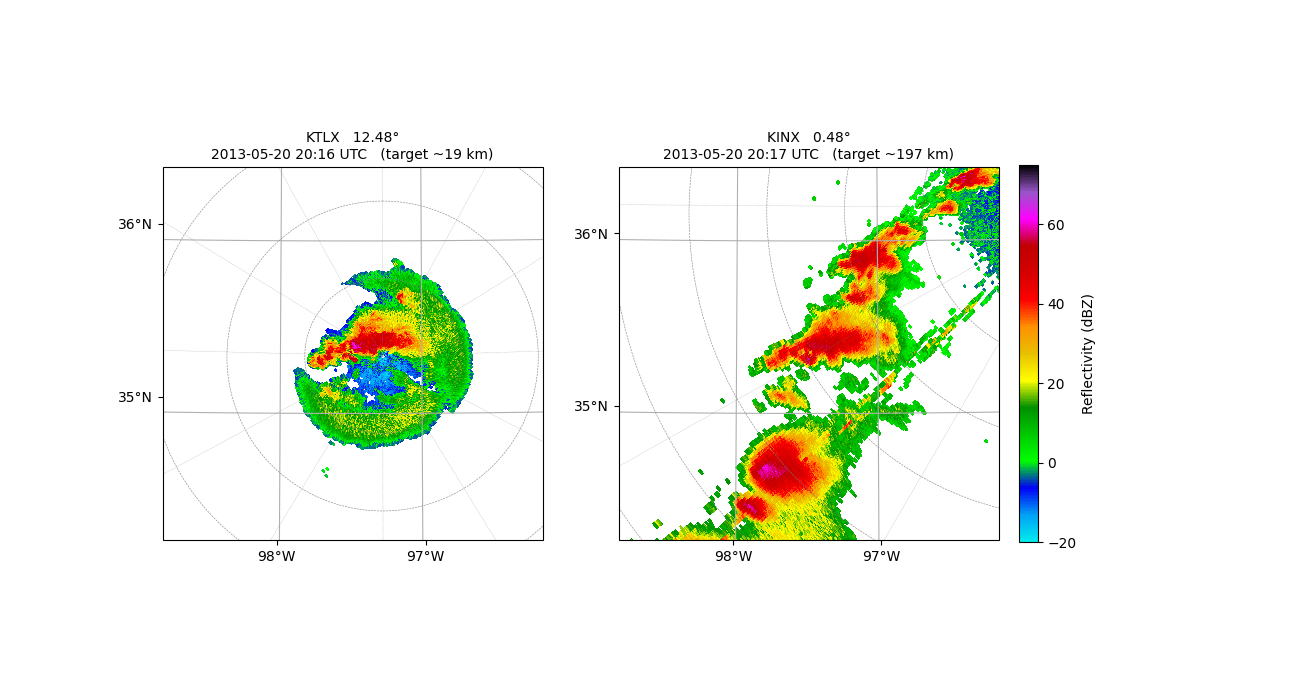

In [13]:
plot_cases(
    ["s3://unidata-nexrad-level2/2013/05/20/KTLX/KTLX20130520_201643_V06.gz",
     "s3://unidata-nexrad-level2/2013/05/20/KINX/KINX20130520_201750_V06.gz"],
    #sweep=[0, 0],
    sweep=[14, 0],
    center=(35.34, -97.49),   # Moore, OK — the storm
    max_range=120)

**Basic**

1. Zoom both panels in on the storm. Which one is sharper — tighter core, finer structure, higher peak reflectivity? Which radar is that, the near one or the far one?
2. The storm is physically identical in both panels. Which idea from this block explains why the far radar's version looks bigger and blurrier with a lower peak?

**A little further**

1. The far storm isn't only weaker — it's physically *broader* on the display. Can sampling higher in the storm (beam height) make an echo wider? If not, what does the broadening prove is happening on its own, regardless of beam height? (Beam width ≈ r·θ — about 0.3 km at KTLX, but ~3.3 km at KINX.)
2. Look at the storm's faint edges and the weak echo around it. Which panel shows less of it? Connect this to the radar-equation widget: why does the far radar's minimum detectable Z sit higher, so it misses the weak periphery the near radar still catches?

**Going deeper**

1. Remove the confound entirely. At 200 km, KINX's 0.5° beam is sampling about 4 km up. Using the beam-height idea (or Block 1's widget), verify that the KTLX tilt that *also* reaches ~4 km at 20 km is a high tilt, around 12°. Re-plot KTLX at that tilt (sweep 14): now both panels sample the same height of the storm, so any sharpness and peak difference that remains is **pure beam width** — resolution and beam filling, with beam height subtracted out. Does the far storm still look broader?
2. Estimate the ratio of the two sample volumes at the storm. Both cross-beam dimensions scale with range (≈ r·θ) and the depth cτ/2 ≈ 0.25 km is the same for both, so the volume grows as r². With KINX at ~10× the range of KTLX, how many times more air does one KINX pixel average over — and what does smearing the storm across that much more atmosphere do to its peak reflectivity?

## Block 2 takeaway
**One radar value is a volume-sized average whose size and detectability you set by trading resolution, sensitivity, and range against each other — so a distant pixel is a large spatial average, a possibly-underestimated peak, and a detection threshold, all at once.**